# Carregamento e Predição com Modelo Treinado — Log-retorno de Preços

**Disciplina:** Projeto de Deep Learning

**Curso:** Ciência de Dados e IA

**Professor(a):** Renan Santos Mendes

**Email:** renansantosmendes@gmail.com

---

Este notebook carrega, a partir do Weights and Biases (`wandb`), o modelo
de rede neural feed-forward treinado no notebook anterior para prever o
log-retorno diario de uma acao a partir de uma janela de valores
passados. Alem de carregar o modelo, este notebook implementa uma
funcao de predicao que aplica o modelo sobre uma serie de precos e
compara visualmente a serie original com a serie reconstruida a partir
das predicoes.

## Estrutura do notebook

1. Instalacao e importacao das bibliotecas
2. Autenticacao no Weights and Biases
3. Definicao da arquitetura do modelo
4. Funcao de carregamento do modelo treinado
5. Coleta de dados para demonstracao da predicao
6. Funcoes de predicao e visualizacao
7. Execucao da predicao sobre a serie coletada

## Instalacao e importacao das bibliotecas

A celula abaixo instala os pacotes necessarios utilizando o `uv` como
gerenciador de pacotes. O pacote `pgl-utils` fornece as funcoes de
plotagem reaproveitadas do notebook de treinamento, `yfinance` e
utilizado para coletar os precos historicos usados na demonstracao da
predicao, e `wandb` e utilizado para baixar o artifact com o modelo
treinado.

In [1]:
!uv pip install pgl-utils yfinance wandb -q

In [2]:
from __future__ import annotations

import os

import numpy as np
import pandas as pd
import torch
import wandb
import yfinance as yf

from pgl_utils.deep_learning import (
    plot_time_series,
    plot_two_series_comparison,
)

In [3]:
from dotenv import load_dotenv

load_dotenv()

True

## Autenticacao no Weights and Biases

O modelo treinado foi salvo como um artifact no `wandb`, portanto e
necessario autenticar antes de baixa-lo. Assim como no notebook de
treinamento, utilizamos `wandb.login(anonymous="allow")`, que permite
executar o notebook sem a necessidade de uma conta propria. A chave de
API pode ser sobrescrita atraves da variavel de ambiente
`WANDB_API_KEY`, mantendo um valor padrao apenas para fins de
demonstracao.

In [5]:
WANDB_API_KEY = os.environ.get(
    "WANDB_API_KEY"
)

try:
    wandb.login(anonymous="allow", timeout=10, key=WANDB_API_KEY)
    WANDB_MODE = "online"
except Exception as login_error:
    print(f"[wandb] Could not log in ({login_error}); falling back to disabled tracking.")
    WANDB_MODE = "disabled"


wandb: WARNING The anonymous parameter to wandb.login() has no effect and will be removed in future versions.
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\09178515602\_netrc
wandb: Currently logged in as: renansantosmendes to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Definicao da arquitetura do modelo

A classe abaixo reproduz exatamente a arquitetura utilizada no
notebook de treinamento: duas camadas ocultas com ativacao `ReLU`,
seguidas de uma camada de saida linear que produz o log-retorno
previsto. E necessario redefinir a classe aqui porque o `state_dict`
salvo no artifact so pode ser carregado em um modelo com a mesma
arquitetura.

In [6]:
class FeedForwardRegressionModel(torch.nn.Module):
    """Feed-forward neural network with two hidden layers.

    The network receives a window of past normalized log-return
    values and predicts the next normalized log-return value. It is
    composed of two hidden linear layers with ReLU activations,
    followed by a linear output layer.

    Args:
        input_window_size (int): Number of past values used as
            input to the network.
        hidden_layer_size (int): Number of units in each hidden
            layer.

    Returns:
        None: This is a constructor and does not return a value.
    """

    def __init__(
        self,
        input_window_size: int,
        hidden_layer_size: int,
    ) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(input_window_size, hidden_layer_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_layer_size, hidden_layer_size),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden_layer_size, 1),
        )

    def forward(self, input_window: torch.Tensor) -> torch.Tensor:
        """Compute the predicted next value from the input window.

        Args:
            input_window (torch.Tensor): Tensor of shape
                (batch_size, input_window_size) containing the
                normalized log-return values used as input.

        Returns:
            torch.Tensor: Tensor of shape (batch_size, 1) with the
            predicted normalized log-return value.
        """
        return self.network(input_window)


## Funcao de carregamento do modelo treinado

A funcao `load_trained_model` baixa o artifact indicado do `wandb`,
le os hiperparametros e as estatisticas de normalizacao salvos em seu
metadata, reconstroi o modelo com a arquitetura correta e carrega os
pesos treinados. O caminho do artifact pode ser sobrescrito pela
variavel de ambiente `WANDB_MODEL_ARTIFACT`.

In [7]:
WANDB_MODEL_ARTIFACT = os.environ.get(
    "WANDB_MODEL_ARTIFACT",
    "renansantosmendes/pytorch-tensores-log-return/pytorch-logreturn-regressor:latest",
)


def load_trained_model(
    wandb_artifact_path: str,
) -> tuple[FeedForwardRegressionModel, float, float]:
    """Download and load a trained model from a wandb artifact.

    Args:
        wandb_artifact_path (str): Fully qualified artifact path in
            the format "entity/project/artifact_name:version".

    Returns:
        tuple[FeedForwardRegressionModel, float, float]: A tuple
        containing the loaded model in evaluation mode, the mean of
        the training log-return series, and the standard deviation
        of the training log-return series.

    Example:
        >>> model, mean, std = load_trained_model(
        ...     "entity/project/artifact:latest"
        ... )
    """
    wandb_api = wandb.Api()
    artifact = wandb_api.artifact(wandb_artifact_path)
    artifact_directory = artifact.download()

    hidden_layer_size = artifact.metadata["hidden_layer_size"]
    input_window_size = artifact.metadata["window_size"]
    return_train_mean = artifact.metadata["return_train_mean"]
    return_train_std = artifact.metadata["return_train_std"]

    trained_model = FeedForwardRegressionModel(
        input_window_size=input_window_size,
        hidden_layer_size=hidden_layer_size,
    )
    model_weights_path = f"{artifact_directory}/regression_model.pt"
    trained_model.load_state_dict(
        torch.load(model_weights_path, map_location="cpu")
    )
    trained_model.eval()

    print(
        f"Model loaded: window_size={input_window_size}, "
        f"hidden_layer_size={hidden_layer_size}"
    )
    print(
        f"Artifact used: {wandb_artifact_path} "
        f"(resolved version: {artifact.version})"
    )
    return trained_model, return_train_mean, return_train_std


### Executando o carregamento

A celula abaixo executa `load_trained_model` e armazena o modelo
carregado, junto com a media e o desvio padrao dos log-retornos de
treino, que sao necessarios para normalizar e desnormalizar valores
durante a predicao.

In [8]:
trained_model, return_train_mean, return_train_std = load_trained_model(
    WANDB_MODEL_ARTIFACT
)

trained_model

wandb:   1 of 1 files downloaded.  


Model loaded: window_size=30, hidden_layer_size=64
Artifact used: renansantosmendes/pytorch-tensores-log-return/pytorch-logreturn-regressor:latest (resolved version: v4)


FeedForwardRegressionModel(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

## Coleta de dados para demonstracao da predicao

Para demonstrar a funcao de predicao, coletamos novamente os precos
historicos da mesma acao utilizada no treinamento, atraves da funcao
`fetch_price_series`, reaproveitada do notebook de treinamento. Os
valores de `TICKER_SYMBOL`, `START_DATE` e `END_DATE` podem ser
ajustados para outra acao ou periodo, desde que a janela de entrada do
modelo (`return_train_mean` e `return_train_std`) continue fazendo
sentido para a nova serie.

In [9]:
TICKER_SYMBOL = "AAPL"
START_DATE = "2020-01-01"
END_DATE = "2026-01-01"


def fetch_price_series(
    ticker_symbol: str,
    start_date: str,
    end_date: str,
) -> pd.DataFrame:
    """Fetch daily closing price data for a given ticker.

    Args:
        ticker_symbol (str): Ticker symbol recognized by Yahoo
            Finance (e.g. "AAPL").
        start_date (str): Start date in "YYYY-MM-DD" format.
        end_date (str): End date in "YYYY-MM-DD" format.

    Returns:
        pd.DataFrame: Single-column DataFrame indexed by date, with
        a "close_price" column holding the daily closing price.
    """
    raw_data = yf.download(
        ticker_symbol,
        start=start_date,
        end=end_date,
        progress=True,
    )
    price_data = raw_data[["Close"]].dropna()
    price_data.columns = ["close_price"]
    return price_data


price_data = fetch_price_series(TICKER_SYMBOL, START_DATE, END_DATE)
price_data.head()


[*********************100%***********************]  1 of 1 completed


,close_price
Date,
2020-01-02,72.271568
2020-01-03,71.568924
2020-01-06,72.139214
2020-01-07,71.799919
2020-01-08,72.954918


## Funcoes de predicao e visualizacao

Duas funcoes sao definidas nesta secao:

- `predict_log_returns`: percorre a serie de log-retornos com uma
  janela deslizante e utiliza o modelo carregado para prever o
  log-retorno seguinte a cada janela, ja normalizando a entrada e
  desnormalizando a saida com as estatisticas de treino.
- `predict_and_plot_price_series`: funcao de mais alto nivel, que
  recebe diretamente a serie de precos, calcula os log-retornos,
  chama `predict_log_returns`, reconstroi os precos previstos e exibe
  dois graficos: a serie original de precos (via `plot_time_series`)
  e a comparacao entre o preco real e o preco reconstruido a partir da
  predicao (via `plot_two_series_comparison`).

In [10]:
def predict_log_returns(
    trained_model: FeedForwardRegressionModel,
    log_return_series: np.ndarray,
    input_window_size: int,
    return_train_mean: float,
    return_train_std: float,
) -> np.ndarray:
    """Predict the next log-return for every window in a series.

    Slides a window of size ``input_window_size`` across
    ``log_return_series`` and uses the trained model to predict the
    log-return that follows each window. The input windows are
    normalized with the training statistics before being fed to the
    model, and the predictions are denormalized back to the
    original log-return scale before being returned.

    Args:
        trained_model (FeedForwardRegressionModel): Model already
            loaded and set to evaluation mode.
        log_return_series (np.ndarray): One-dimensional array with
            the raw (non-normalized) log-return values.
        input_window_size (int): Number of past values used as
            input to the model, must match the value used during
            training.
        return_train_mean (float): Mean of the training log-return
            series, used to normalize the input windows.
        return_train_std (float): Standard deviation of the
            training log-return series, used to normalize the
            input windows.

    Returns:
        np.ndarray: One-dimensional array with the predicted
        (denormalized) log-return for every window in
        ``log_return_series``. Its length equals
        ``len(log_return_series) - input_window_size``.

    Example:
        >>> predicted = predict_log_returns(
        ...     trained_model,
        ...     log_return_series,
        ...     input_window_size=30,
        ...     return_train_mean=0.0004,
        ...     return_train_std=0.018,
        ... )
    """
    normalized_series = (
        log_return_series - return_train_mean
    ) / return_train_std

    number_of_predictions = len(normalized_series) - input_window_size
    input_windows = np.stack(
        [
            normalized_series[index:index + input_window_size]
            for index in range(number_of_predictions)
        ]
    )
    input_tensor = torch.from_numpy(input_windows.astype(np.float32))

    trained_model.eval()
    with torch.no_grad():
        normalized_predictions = trained_model(input_tensor).squeeze(1)

    predicted_log_returns = (
        normalized_predictions.numpy() * return_train_std
        + return_train_mean
    )
    return predicted_log_returns


def predict_next_n_days_price(
    trained_model: FeedForwardRegressionModel,
    price_series_dataframe: pd.DataFrame,
    input_window_size: int,
    return_train_mean: float,
    return_train_std: float,
    ticker_symbol: str,
    number_of_days_to_predict: int = 1,
    serie_start_date: str | pd.Timestamp | None = None,
) -> pd.DataFrame:
    """Predict an arbitrary number of future daily prices.

    Starting from the last ``input_window_size`` log-returns of
    ``price_series_dataframe``, this function performs a recursive
    (multi-step) forecast: it predicts the log-return for the next
    day, reconstructs the corresponding price, appends this new
    log-return to the input window (dropping the oldest one) and
    repeats the process ``number_of_days_to_predict`` times. Each
    step therefore uses the model's own previous prediction as part
    of the input for the following step.

    Note that because errors accumulate at every step, the
    uncertainty of the forecast grows quickly with
    ``number_of_days_to_predict``; this is expected behavior of any
    recursive multi-step forecast and not a bug.

    Args:
        trained_model (FeedForwardRegressionModel): Model already
            loaded and set to evaluation mode.
        price_series_dataframe (pd.DataFrame): DataFrame with a
            "close_price" column holding the historical closing
            prices, indexed by date.
        input_window_size (int): Number of past values used as
            input to the model, must match the value used during
            training.
        return_train_mean (float): Mean of the training log-return
            series, used to normalize the input windows.
        return_train_std (float): Standard deviation of the
            training log-return series, used to normalize the
            input windows.
        ticker_symbol (str): Ticker symbol used in the chart title.
        number_of_days_to_predict (int): Number of future business
            days to forecast, starting right after the last date in
            ``price_series_dataframe``. Defaults to 1.
        serie_start_date (str | pd.Timestamp | None): Optional date
            used **only to zoom in the plot**. When provided, the
            historical portion of the chart is cropped to dates on
            or after ``serie_start_date``. It has no effect on the
            data used for prediction (the model still uses the full
            history to build its input window) — it only changes
            what is displayed. Defaults to ``None`` (show the full
            historical series).

    Returns:
        pd.DataFrame: DataFrame indexed by the predicted future
        dates, with a single "predicted_close_price" column holding
        the forecasted price for each of those days.

    Example:
        >>> future_prices = predict_next_n_days_price(
        ...     trained_model,
        ...     price_data,
        ...     input_window_size=30,
        ...     return_train_mean=0.0004,
        ...     return_train_std=0.018,
        ...     ticker_symbol="AAPL",
        ...     number_of_days_to_predict=5,
        ... )
    """
    if number_of_days_to_predict < 1:
        raise ValueError("number_of_days_to_predict must be >= 1.")

    price_values = price_series_dataframe["close_price"].to_numpy(
        dtype=np.float32
    )
    log_price_values = np.log(price_values)
    log_return_series = log_price_values[1:] - log_price_values[:-1]

    if len(log_return_series) < input_window_size:
        raise ValueError(
            "Not enough historical data to build a single input "
            f"window of size {input_window_size}."
        )

    trained_model.eval()

    rolling_window = log_return_series[-input_window_size:].astype(
        np.float32
    ).copy()
    last_known_price = float(price_values[-1])
    last_date = price_series_dataframe.index[-1]

    predicted_dates = []
    predicted_prices = []
    current_price = last_known_price
    current_date = last_date

    for _ in range(number_of_days_to_predict):
        normalized_window = (
            rolling_window - return_train_mean
        ) / return_train_std
        input_tensor = torch.from_numpy(
            normalized_window.astype(np.float32)
        ).unsqueeze(0)

        with torch.no_grad():
            normalized_prediction = trained_model(input_tensor).squeeze()

        predicted_log_return = (
            normalized_prediction.item() * return_train_std
            + return_train_mean
        )

        current_price = current_price * np.exp(predicted_log_return)
        current_date = current_date + pd.tseries.offsets.BDay(1)

        predicted_dates.append(current_date)
        predicted_prices.append(current_price)

        rolling_window = np.concatenate(
            [rolling_window[1:], [predicted_log_return]]
        ).astype(np.float32)

    predicted_prices_dataframe = pd.DataFrame(
        {"predicted_close_price": predicted_prices}, index=predicted_dates
    )

    plot_series_dataframe = price_series_dataframe
    if serie_start_date is not None:
        plot_series_dataframe = price_series_dataframe.loc[
            price_series_dataframe.index >= pd.to_datetime(serie_start_date)
        ]

    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 5))
    plt.plot(
        plot_series_dataframe.index,
        plot_series_dataframe["close_price"],
        label="Historical close price",
        color="tab:blue",
    )
    connecting_dates = [last_date] + predicted_dates
    connecting_prices = [last_known_price] + predicted_prices
    plt.plot(
        connecting_dates,
        connecting_prices,
        linestyle="--",
        color="tab:red",
        marker="o",
        label=f"Predicted next {number_of_days_to_predict} day(s)",
    )
    plt.title(
        f"{ticker_symbol} - Predicted Price for the Next "
        f"{number_of_days_to_predict} Day(s)"
    )
    plt.xlabel("Date")
    plt.ylabel("Close price")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Last known price ({last_date.date()}): {last_known_price:.4f}")
    for date, price in zip(predicted_dates, predicted_prices):
        print(f"Predicted price for {date.date()}: {price:.4f}")

    return predicted_prices_dataframe


## Executando a predicao para N dias futuros

A celula abaixo utiliza `predict_next_n_days_price` para gerar a
predicao do preco para um numero arbitrario de dias futuros,
definido pelo parametro `NUMBER_OF_DAYS_TO_PREDICT`. A predicao e
recursiva (multi-step): a cada dia previsto, o log-retorno gerado
pelo modelo e incorporado a janela de entrada para prever o dia
seguinte. Por isso, o erro tende a se acumular a medida que o
horizonte de predicao aumenta — isso e esperado em qualquer
predicao recursiva de multiplos passos, e nao um problema do
codigo.

O parametro `SERIE_START_DATE` controla **somente o zoom do
grafico**: ele recorta a parte historica exibida a partir dessa
data, mas nao altera os dados usados pelo modelo para prever (a
janela de entrada sempre usa o historico completo). Deixe como
`None` para exibir a serie historica inteira no grafico.

Tambem imprimimos o `artifact.version` resolvido (na celula de
carregamento do modelo) e o intervalo de datas de `price_data`
abaixo — se voce rodar o notebook mais de uma vez e a predicao
mudar, compare esses valores entre as execucoes: se o `artifact
version` ou o intervalo/valores de `price_data` forem diferentes,
esse e o motivo (modelo `:latest` foi atualizado no wandb, ou o
Yahoo Finance retornou dados ajustados diferentes); o codigo de
predicao em si e deterministico.

price_data range: 2020-01-02 00:00:00 -> 2025-12-31 00:00:00
price_data last close: 271.12200927734375


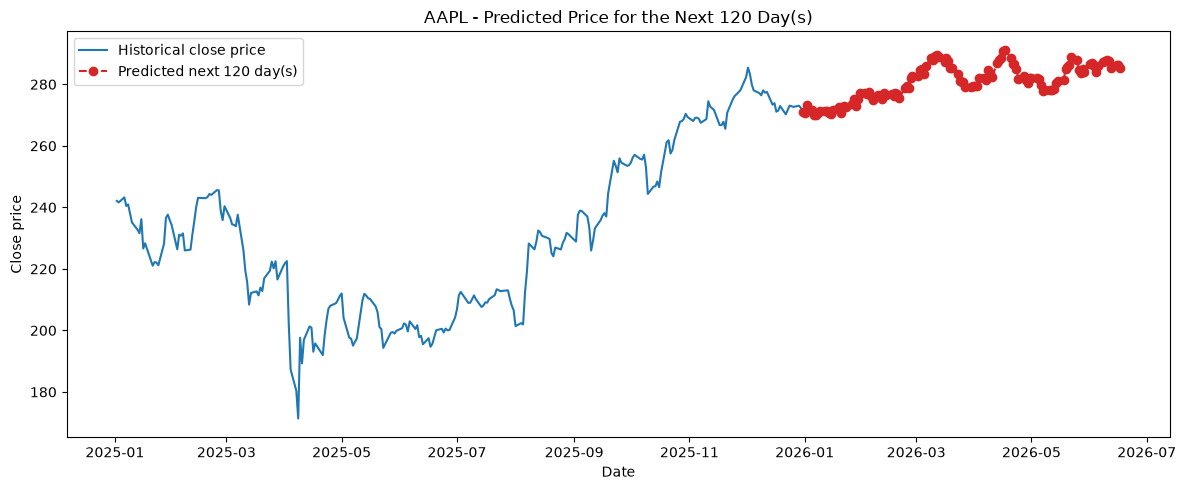

Last known price (2025-12-31): 271.1220
Predicted price for 2026-01-01: 270.5187
Predicted price for 2026-01-02: 273.1772
Predicted price for 2026-01-05: 271.6552
Predicted price for 2026-01-06: 269.8823
Predicted price for 2026-01-07: 270.0497
Predicted price for 2026-01-08: 270.5939
Predicted price for 2026-01-09: 271.4008
Predicted price for 2026-01-12: 271.3677
Predicted price for 2026-01-13: 271.3250
Predicted price for 2026-01-14: 270.6549
Predicted price for 2026-01-15: 270.4723
Predicted price for 2026-01-16: 271.6658
Predicted price for 2026-01-19: 272.7710
Predicted price for 2026-01-20: 270.7227
Predicted price for 2026-01-21: 272.1608
Predicted price for 2026-01-22: 272.9157
Predicted price for 2026-01-23: 272.6111
Predicted price for 2026-01-26: 273.6548
Predicted price for 2026-01-27: 275.0855
Predicted price for 2026-01-28: 272.8157
Predicted price for 2026-01-29: 275.1919
Predicted price for 2026-01-30: 277.0618
Predicted price for 2026-02-02: 277.0831
Predicted price f

,predicted_close_price
2026-01-01,270.518676
2026-01-02,273.177246
2026-01-05,271.655239
2026-01-06,269.882284
2026-01-07,270.049712
...,...
2026-06-11,287.511641
2026-06-12,285.354438
2026-06-15,286.212154
2026-06-16,286.346618


In [12]:
print(f"price_data range: {price_data.index.min()} -> {price_data.index.max()}")
print(f"price_data last close: {price_data['close_price'].iloc[-1]}")

input_window_size = trained_model.network[0].in_features
NUMBER_OF_DAYS_TO_PREDICT = 120  # altere aqui para prever mais ou menos dias
SERIE_START_DATE = "2025-01-01"  # altere aqui para dar zoom no grafico (ou None para ver tudo)

predicted_prices_dataframe = predict_next_n_days_price(
    trained_model=trained_model,
    price_series_dataframe=price_data,
    input_window_size=input_window_size,
    return_train_mean=return_train_mean,
    return_train_std=return_train_std,
    ticker_symbol=TICKER_SYMBOL,
    number_of_days_to_predict=NUMBER_OF_DAYS_TO_PREDICT,
    serie_start_date=SERIE_START_DATE,
)

predicted_prices_dataframe

In [13]:
torch.__version__

'2.13.0+cu130'

In [14]:
torch.cuda.is_available()

True